# Notebook 03 - Análisis Exploratorio de Datos (EDA)

En este notebook se realiza el análisis univariado, bivariado y multivariado
del dataset limpio. Cada visualización incluye una interpretación vinculada
a las preguntas de análisis definidas en la inspección inicial.

In [1]:
# Importamos las librerías necesarias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargamos el dataset limpio
df = pd.read_csv('../data/processed/streaming_users_clean.csv')
print(f"Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas")
print("Máximo watch time:", df['monthly_watch_time_mins'].max())

Dataset cargado: 7884 filas, 8 columnas
Máximo watch time: 2704.7


In [2]:
df = pd.read_csv('../data/processed/streaming_users_clean.csv')

## Análisis Univariado

### Visualización 1 - Distribución de edades

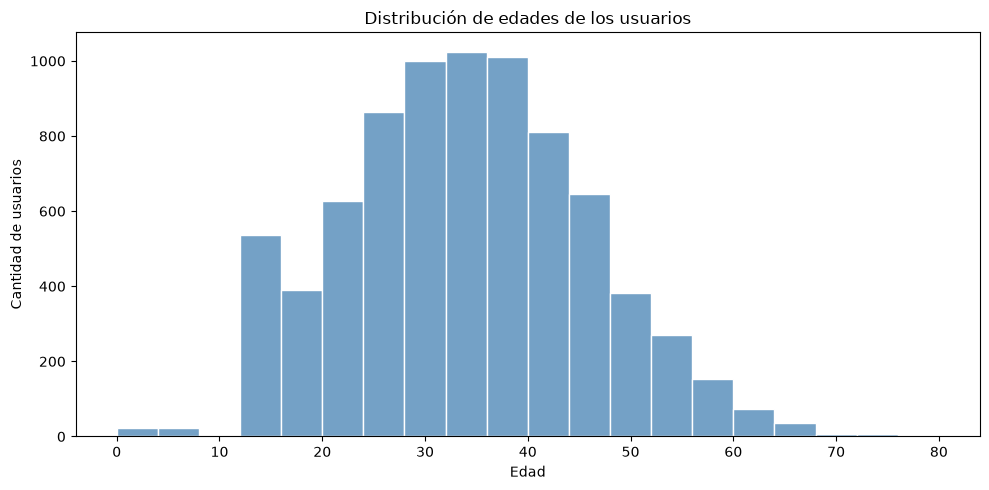

In [3]:
# Distribución de edades de los usuarios
plt.figure(figsize=(10, 5))
sns.histplot(df['age'], bins=20, color='steelblue', edgecolor='white')
plt.title('Distribución de edades de los usuarios')
plt.xlabel('Edad')
plt.ylabel('Cantidad de usuarios')
plt.tight_layout()
plt.show()

**Interpretación:** La distribución de edades se concentra entre los 20 y 50 años,
con mayor frecuencia en la franja de 25 a 40 años. Esto responde parcialmente
a la pregunta sobre si la edad influye en el comportamiento de consumo: la
plataforma tiene una base de usuarios predominantemente adultos jóvenes,
lo que deberá considerarse al analizar patrones de visualización.

### Visualización 2 - Distribución del tiempo mensual de visualización

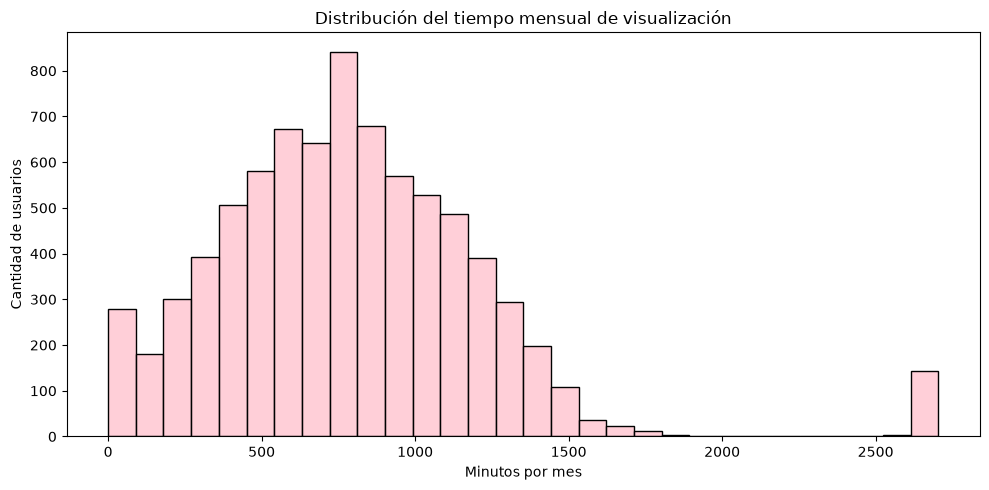

In [4]:
# Distribución del tiempo mensual de visualización
plt.figure(figsize=(10, 5))
sns.histplot(df['monthly_watch_time_mins'], bins=30, color='pink', edgecolor='black')
plt.title('Distribución del tiempo mensual de visualización')
plt.xlabel('Minutos por mes')
plt.ylabel('Cantidad de usuarios')
plt.tight_layout()
plt.show()

**Interpretación:** El tiempo mensual de visualización se distribuye de forma
aproximadamente simétrica, con la mayoría de los usuarios entre 400 y 1200
minutos. La mediana es más representativa que la media dado que la
distribución no presenta asimetría extrema. Este resultado es el punto de
partida para responder si el plan de suscripción influye en el tiempo de consumo.

## Análisis Bivariado

### Visualización 3 - Tiempo de visualización por plan de suscripción

C:\Users\sarac\AppData\Local\Temp\ipykernel_5196\3099667063.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='subscription_plan', y='monthly_watch_time_mins',


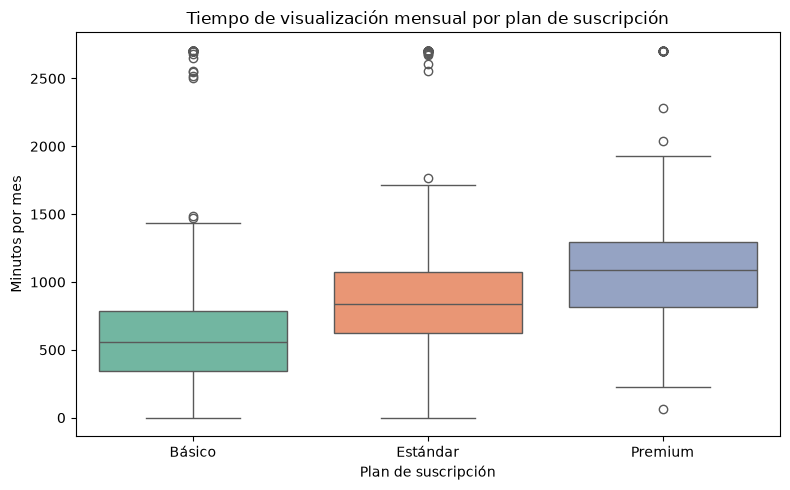

In [5]:
# Tiempo de visualización según el plan de suscripción
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='subscription_plan', y='monthly_watch_time_mins',
            palette='Set2', order=['Básico', 'Estándar', 'Premium'])
plt.title('Tiempo de visualización mensual por plan de suscripción')
plt.xlabel('Plan de suscripción')
plt.ylabel('Minutos por mes')
plt.tight_layout()
plt.show()

**Interpretación:** Los tres planes de suscripción muestran distribuciones
de tiempo de visualización similares, sin diferencias marcadas entre ellos.
Esto sugiere que el plan contratado no determina cuánto consume el usuario,
lo que responde negativamente a la primera pregunta de análisis: el tiempo
de consumo parece ser independiente del plan de suscripción.

### Visualización 4 - Tickets de soporte por país

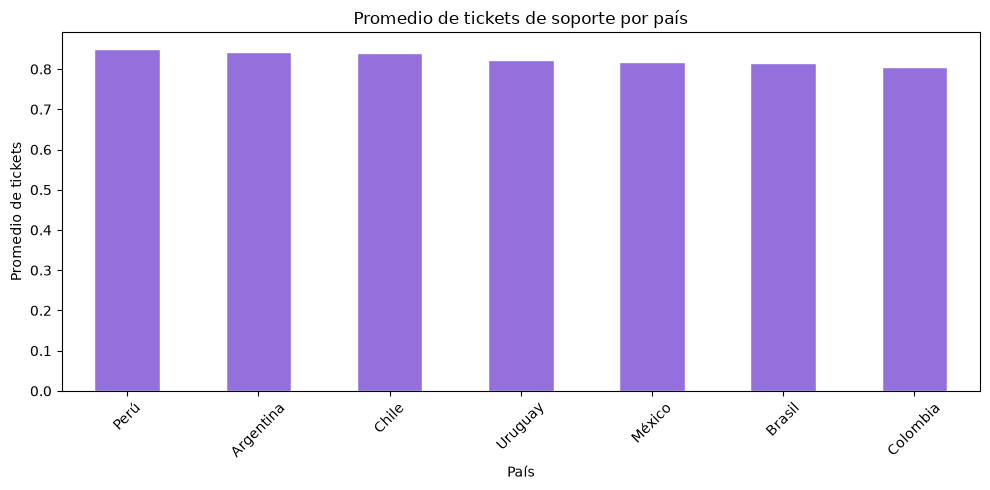

In [6]:
# Promedio de tickets de soporte por país
tickets_pais = df.groupby('country')['customer_support_tickets'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
tickets_pais.plot(kind='bar', color='mediumpurple', edgecolor='white')
plt.title('Promedio de tickets de soporte por país')
plt.xlabel('País')
plt.ylabel('Promedio de tickets')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Interpretación:** El promedio de tickets de soporte varía entre países,
lo que indica diferencias en la experiencia del usuario según la región.
Esto aporta evidencia parcial a la pregunta sobre si los usuarios con más
tickets tienen menor tiempo de uso: primero es necesario identificar
qué países generan más tickets para luego cruzar esa información con
el tiempo de visualización.

## Análisis Multivariado

### Visualización 5 - Mapa de calor de correlaciones

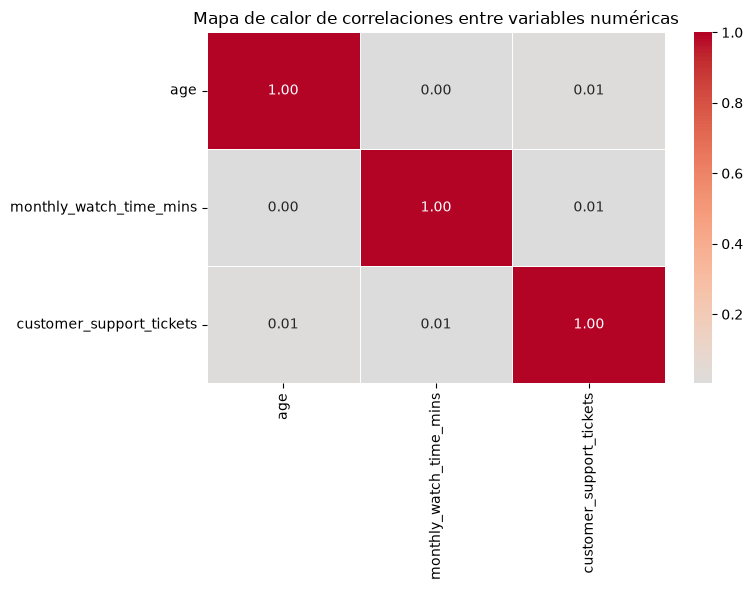

In [7]:
# Mapa de calor de correlaciones entre variables numéricas
variables_numericas = df[['age', 'monthly_watch_time_mins', 'customer_support_tickets']]

plt.figure(figsize=(8, 6))
sns.heatmap(variables_numericas.corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Mapa de calor de correlaciones entre variables numéricas')
plt.tight_layout()
plt.show()

**Interpretación:** El mapa de correlaciones muestra que ninguna de las tres
variables numéricas presenta correlación fuerte entre sí. La correlación
más cercana a cero entre tickets de soporte y tiempo de visualización
responde negativamente a la cuarta pregunta de análisis: los usuarios
que generan más tickets no parecen consumir significativamente menos
contenido. La baja correlación general también justifica incluir las tres
variables en el PCA, ya que no son redundantes entre sí.